In [44]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

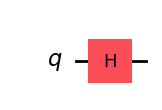

In [45]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [46]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [47]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [48]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [49]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

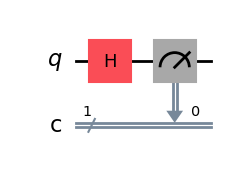

In [50]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [51]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [52]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 509, '1': 515}


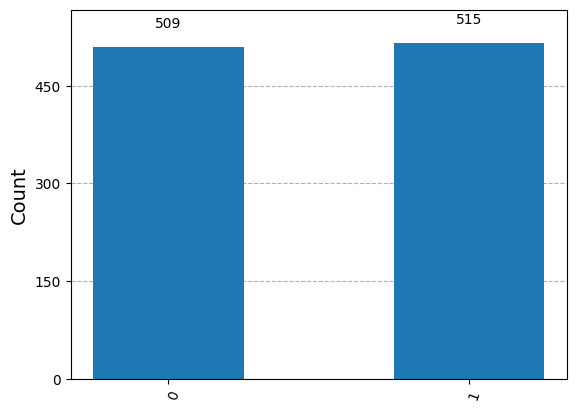

In [53]:
# We can also produce a graph

plot_histogram(counts)

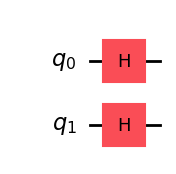

In [54]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [55]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

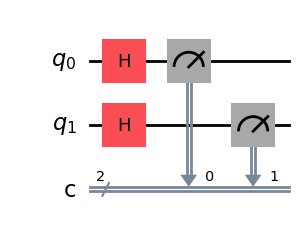

In [56]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

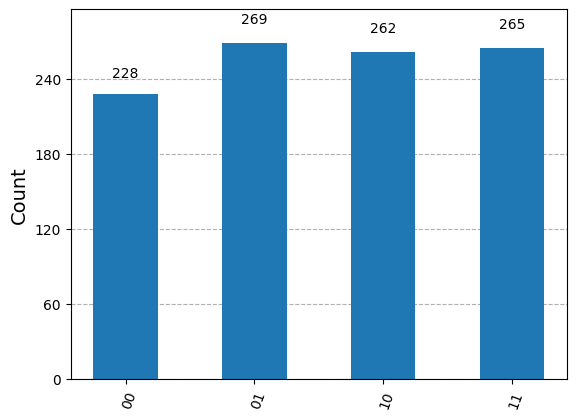

In [57]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

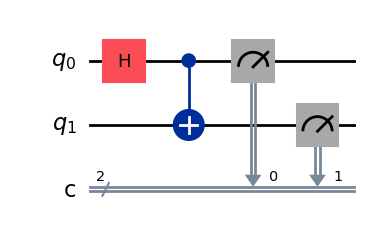

In [58]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

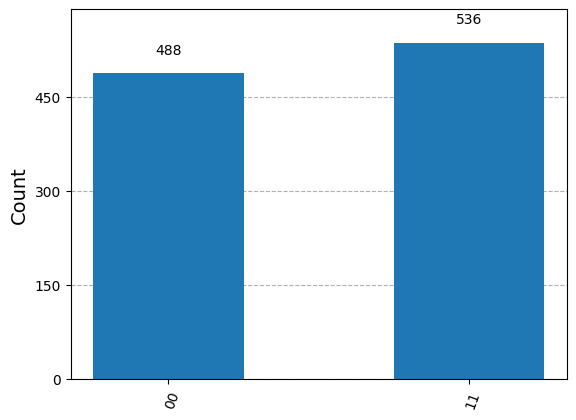

In [59]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [64]:
# EXERCISE

backend = BasicSimulator()

# Make a copy here of the circuit that creates the Bell state

#1/sqrt(2) ( |00> + |11> ).
circuit_1 = QuantumCircuit(2,2)
circuit_1.h(0)
circuit_1.cx(0,1)
circuit_1.measure(range(2),range(2))


# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
# Modify it to create the other Bell states:

# 1/sqrt(2) ( |00> - |11> ),
circuit_2 = QuantumCircuit(2,2)
circuit_2.h(0)
circuit_2.cx(0,1)
circuit.z(0)
circuit_2.measure(range(2),range(2))

# 1/sqrt(2) ( |01> + |10> ),

circuit_3 = QuantumCircuit(2,2)
circuit_3.h(0)
circuit_3.x(1)
circuit_3.cx(0,1)
circuit_3.measure(range(2),range(2))

# 1/sqrt(2) ( |01> - |10> ).

circuit_4 = QuantumCircuit(2,2)
circuit_4.h(0)
circuit_4.x(1)
circuit_4.cx(0,1)
circuit_4.z(0)
circuit_4.measure(range(2),range(2))


# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.
t_qc1 = transpile(circuit_1, backend)
counts1 = backend.run(t_qc1, shots=1024).result().get_counts()
print(f"Phi+ Results: {counts1}")

t_qc2 = transpile(circuit_2, backend)
counts2= backend.run(t_qc2, shots=1024).result().get_counts()
print(f"Phi+ Results: {counts2}")

t_qc3 = transpile(circuit_3, backend)
counts3= backend.run(t_qc3, shots=1024).result().get_counts()
print(f"Phi+ Results: {counts3}")

t_qc4 = transpile(circuit_4, backend)
counts4= backend.run(t_qc4, shots=1024).result().get_counts()
print(f"Phi+ Results: {counts4}")

Phi+ Results: {'11': 511, '00': 513}
Phi+ Results: {'00': 543, '11': 481}
Phi+ Results: {'01': 535, '10': 489}
Phi+ Results: {'10': 495, '01': 529}


--- Circuit Diagram for 3 Qubits ---


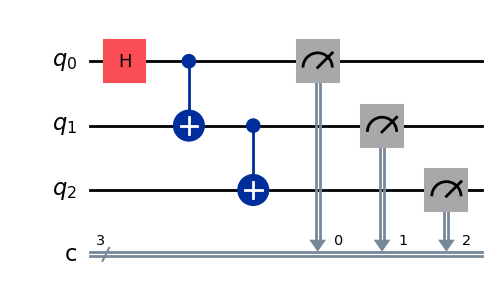

--- Simulation Results (3 Qubits) ---
{'000': 525, '111': 499}


In [70]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

def run_ghz_experiment(n_qubits):
    # 1. Construct the GHZ Circuit
    # Create a circuit with n qubits and n classical bits
    circuit = QuantumCircuit(n_qubits, n_qubits)

    # Step A: Put the first qubit (index 0) into a 50/50 superposition
    # This creates the state: 1/sqrt(2) (|0> + |1>)
    circuit.h(0)

    # Step B: Entangle the rest of the qubits
    # We use a 'CNOT chain' where each qubit acts as a control for the next
    for i in range(n_qubits - 1):
        circuit.cx(i, i + 1)

    # Step C: Add measurements
    # Map each quantum wire to its corresponding classical bit
    circuit.measure(range(n_qubits), range(n_qubits))

    # 2. Visualize the Circuit
    print(f"--- Circuit Diagram for {n_qubits} Qubits ---")
    # Using 'mpl' for a high-quality drawing
    display(circuit.draw("mpl"))

    # 3. Simulate the Circuit
    # Use BasicSimulator to mimic hardware behavior
    backend = BasicSimulator()

    # Transpile the circuit for the specific backend
    t_circuit = transpile(circuit, backend)

    # Run the simulation for 1024 repetitions (shots)
    job = backend.run(t_circuit, shots=1024)
    result = job.result()

    # Grab the counts (how many times each state was observed)
    counts = result.get_counts()

    print(f"--- Simulation Results ({n_qubits} Qubits) ---")
    print(counts)

    return counts
results = run_ghz_experiment(3)
